In [3]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
import os
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv('C:/Users/Stefan/SBC/Hate_Speech_Recon/Data/Raw/train.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head(10))

Dataset Shape: (24783, 6)

Columns: ['count', 'hate_speech_count', 'offensive_language_count', 'neither_count', 'class', 'tweet']

First few rows:
   count  hate_speech_count  offensive_language_count  neither_count  class  \
0      3                  0                         0              3      2   
1      3                  0                         3              0      1   
2      3                  0                         3              0      1   
3      3                  0                         2              1      1   
4      6                  0                         6              0      1   
5      3                  1                         2              0      1   
6      3                  0                         3              0      1   
7      3                  0                         3              0      1   
8      3                  0                         3              0      1   
9      3                  1                         2          

In [3]:
print("="*70)
print("DATASET INFORMATION")
print("="*70)
print(f"\nTotal Tweets: {len(df):,}")
print(f"\nColumn Data Types:")
print(df.dtypes)
print(f"\nMissing Values:")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal Missing: {missing.sum()}")
print(f"\nBasic Statistics:")
print(df.describe())

DATASET INFORMATION

Total Tweets: 24,783

Column Data Types:
count                        int64
hate_speech_count            int64
offensive_language_count     int64
neither_count                int64
class                        int64
tweet                       object
dtype: object

Missing Values:
count                       0
hate_speech_count           0
offensive_language_count    0
neither_count               0
class                       0
tweet                       0
dtype: int64

Total Missing: 0

Basic Statistics:
              count  hate_speech_count  offensive_language_count  \
count  24783.000000       24783.000000              24783.000000   
mean       3.243473           0.280515                  2.413711   
std        0.883060           0.631851                  1.399459   
min        3.000000           0.000000                  0.000000   
25%        3.000000           0.000000                  2.000000   
50%        3.000000           0.000000                  3.0

In [4]:
class_map = {
    0: 'Hate Speech',
    1: 'Offensive Language',
    2: 'Neither'
}

df['class_name'] = df['class'].map(class_map)

print("="*70)
print("CLASS DISTRIBUTION")
print("="*70)
print(f"\n{df['class_name'].value_counts()}")
print(f"\nPercentage Distribution:")
print(df['class_name'].value_counts(normalize=True) * 100)
print(f"\nSample of class mapping:")
print(df[['class', 'class_name']].head(10))

CLASS DISTRIBUTION

class_name
Offensive Language    19190
Neither                4163
Hate Speech            1430
Name: count, dtype: int64

Percentage Distribution:
class_name
Offensive Language    77.432111
Neither               16.797805
Hate Speech            5.770084
Name: proportion, dtype: float64

Sample of class mapping:
   class          class_name
0      2             Neither
1      1  Offensive Language
2      1  Offensive Language
3      1  Offensive Language
4      1  Offensive Language
5      1  Offensive Language
6      1  Offensive Language
7      1  Offensive Language
8      1  Offensive Language
9      1  Offensive Language


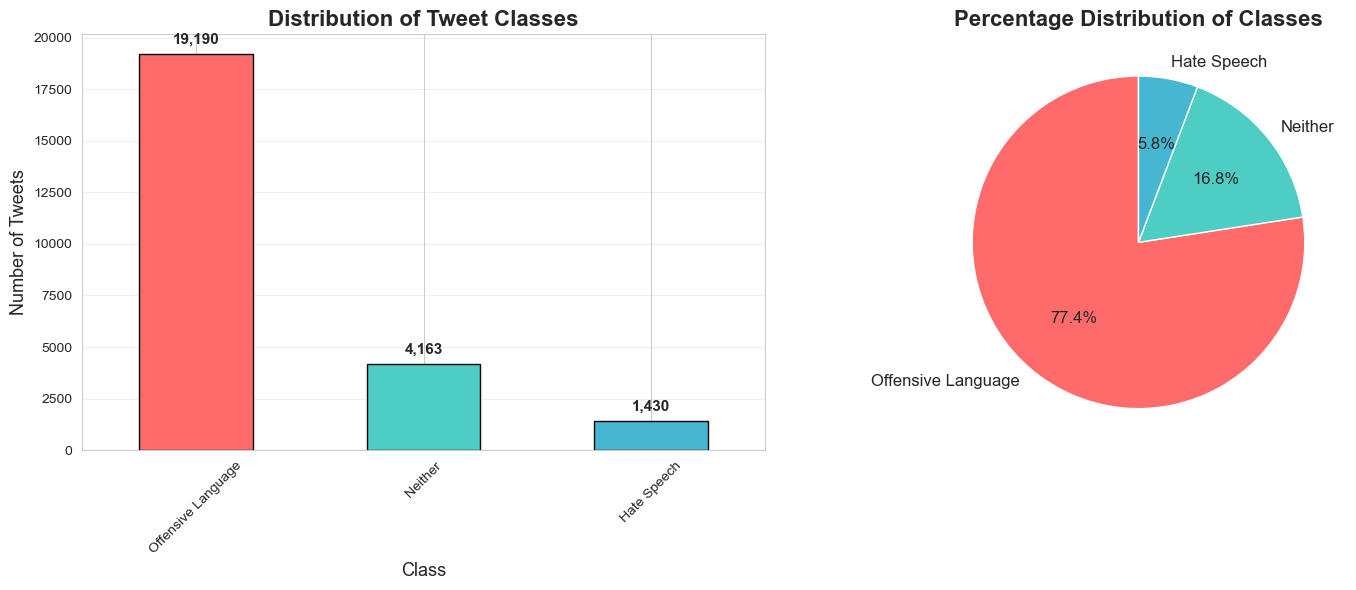

Class distribution plot saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Outputs/Figures/class_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#Bar plot
class_counts = df['class_name'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
class_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Distribution of Tweet Classes', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=13)
axes[0].set_ylabel('Number of Tweets', fontsize=13)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

#Pie chart
class_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                  colors=colors, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Percentage Distribution of Classes', fontsize=16, fontweight='bold')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('C:/Users/Stefan/SBC/Hate_Speech_Recon/Outputs/Figures/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Class distribution plot saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Outputs/Figures/class_distribution.png")

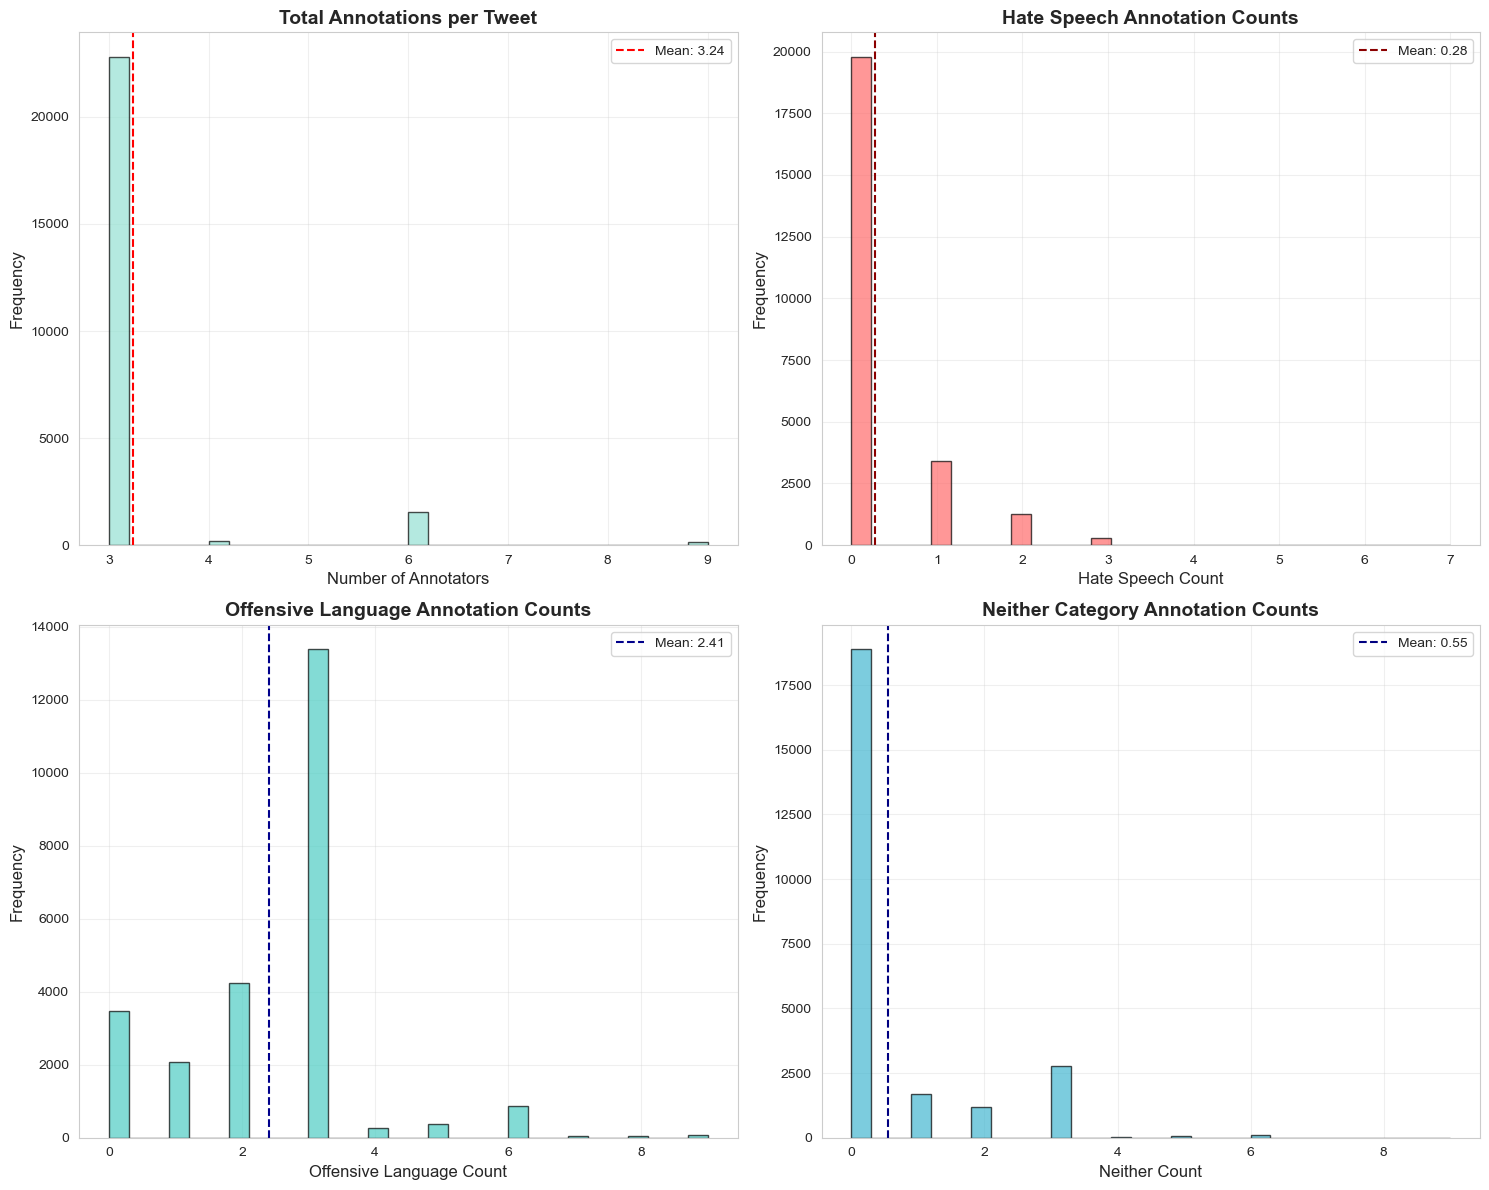

Annotation distribution plot saved


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes[0, 0].hist(df['count'], bins=30, color='#95E1D3', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Total Annotations per Tweet', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Annotators', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].axvline(df['count'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {df["count"].mean():.2f}')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(df['hate_speech_count'], bins=30, color='#FF6B6B', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Hate Speech Annotation Counts', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Hate Speech Count', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].axvline(df['hate_speech_count'].mean(), color='darkred', linestyle='--',
                   label=f'Mean: {df["hate_speech_count"].mean():.2f}')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].hist(df['offensive_language_count'], bins=30, color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Offensive Language Annotation Counts', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Offensive Language Count', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].axvline(df['offensive_language_count'].mean(), color='darkblue', linestyle='--',
                   label=f'Mean: {df["offensive_language_count"].mean():.2f}')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].hist(df['neither_count'], bins=30, color='#45B7D1', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Neither Category Annotation Counts', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Neither Count', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].axvline(df['neither_count'].mean(), color='navy', linestyle='--',
                   label=f'Mean: {df["neither_count"].mean():.2f}')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('C:/Users/Stefan/SBC/Hate_Speech_Recon/Outputs/Figures/annotation_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Annotation distribution plot saved")

TEXT LENGTH STATISTICS

Overall Statistics:
 Average tweet length: 85.44 characters
 Average word count: 14.12 words

By Class:

  Hate Speech:
    Avg length: 84.59 chars
    Avg words: 13.91 words

  Offensive Language:
    Avg length: 83.46 chars
    Avg words: 13.96 words

  Neither:
    Avg length: 94.85 chars
    Avg words: 14.92 words


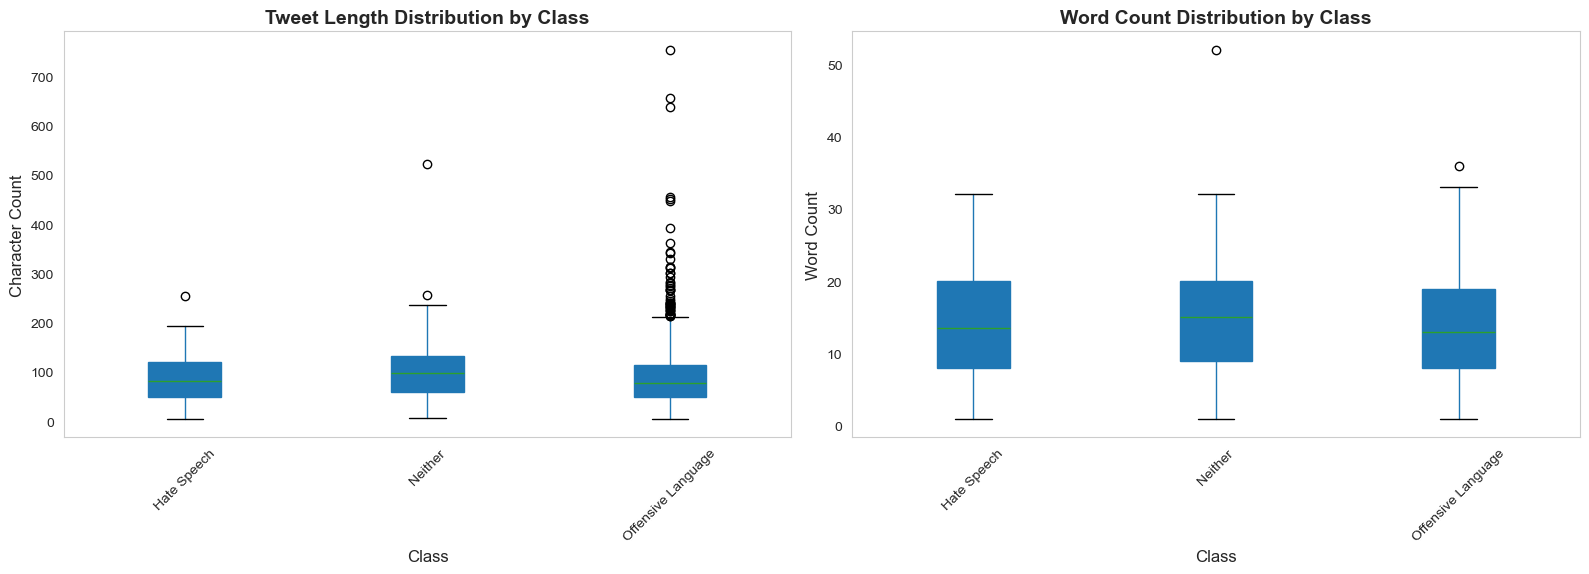


Text length analysis plot saved


In [8]:
df['tweet_length'] = df['tweet'].astype(str).apply(len)
df['word_count'] = df['tweet'].astype(str).apply(lambda x: len(x.split()))

print("="*70)
print("TEXT LENGTH STATISTICS")
print("="*70)
print(f"\nOverall Statistics:")
print(f" Average tweet length: {df['tweet_length'].mean():.2f} characters")
print(f" Average word count: {df['word_count'].mean():.2f} words")

print(f"\nBy Class:")
for class_name in ['Hate Speech', 'Offensive Language', 'Neither']:
    class_df = df[df['class_name'] == class_name]
    print(f"\n  {class_name}:")
    print(f"    Avg length: {class_df['tweet_length'].mean():.2f} chars")
    print(f"    Avg words: {class_df['word_count'].mean():.2f} words")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df.boxplot(column='tweet_length', by='class_name', ax=axes[0], 
           patch_artist=True, grid=False)
axes[0].set_title('Tweet Length Distribution by Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Character Count', fontsize=12)
axes[0].get_figure().suptitle('')  # Remove automatic title
plt.sca(axes[0])
plt.xticks(rotation=45)

df.boxplot(column='word_count', by='class_name', ax=axes[1],
           patch_artist=True, grid=False)
axes[1].set_title('Word Count Distribution by Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Word Count', fontsize=12)
axes[1].get_figure().suptitle('')  # Remove automatic title
plt.sca(axes[1])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('C:/Users/Stefan/SBC/Hate_Speech_Recon/Outputs/Figures/text_length_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nText length analysis plot saved")

In [9]:
print("="*70)
print("SAMPLE TWEETS FROM EACH CLASS")
print("="*70)
for class_num in [0, 1, 2]:
    class_name = class_map[class_num]
    print(f"\n{class_name} (Class {class_num}):")
    print("-" * 70)
    samples = df[df['class'] == class_num].sample(min(3, len(df[df['class'] == class_num])))
    for idx, row in samples.iterrows():
        print(f"  • {row['tweet'][:100]}...")
        print()

SAMPLE TWEETS FROM EACH CLASS

Hate Speech (Class 0):
----------------------------------------------------------------------
  • I hope you get eye cancer bitch....

  • @holyh00ker he looks like a pretty dyke&#128129;&#10024;...

  • Hey. @BarackObama. Don't be like a stupid white bitch in some horror movie asks #America to hide fro...


Offensive Language (Class 1):
----------------------------------------------------------------------
  • RT @KushDahGodd: Five things I'll never give a bitch&#9757;&#65039;

1:My Heart
2:My Weed
3:My Money...

  • RT @rebelGANJA: &#8220;@1BookieG: Idk why I love skinny girls&#8221; they got good pussy &#9994;...

  • RT @HBCUfessions: Am I the only nigga that fucked a "virgin" expecting her to scream. She wasn't eve...


Neither (Class 2):
----------------------------------------------------------------------
  • RT @CloydRiversPics: Ran outside mullet flowin', nips shown'. Shotgunned a cold one and yelled, "Sat...

  • my grandma got a rosta colored 

In [10]:
print("="*70)
print("DATA QUALITY CHECKS")
print("="*70)

duplicates = df.duplicated(subset=['tweet']).sum()
print(f"\nDuplicate tweets: {duplicates}")

print(f"\nAnnotation Consistency Check:")
print(f"  Tweets where count != sum of annotations:")
df['annotation_sum'] = (df['hate_speech_count'] + 
                        df['offensive_language_count'] + 
                        df['neither_count'])
inconsistent = df[df['count'] != df['annotation_sum']]
print(f"  Count: {len(inconsistent)}")

if len(inconsistent) == 0:
    print("  ✓ All annotations are consistent!")

empty_tweets = df[df['tweet'].astype(str).str.strip() == ''].shape[0]
print(f"\nEmpty tweets: {empty_tweets}")

print("\n" + "="*70)
print("✓ DATA EXPLORATION COMPLETE!")
print("="*70)
print(f"\nKey Findings:")
print(f"  • Total tweets: {len(df):,}")
print(f"  • Offensive Language: {len(df[df['class']==1]):,} ({len(df[df['class']==1])/len(df)*100:.1f}%)")
print(f"  • Neither: {len(df[df['class']==2]):,} ({len(df[df['class']==2])/len(df)*100:.1f}%)")
print(f"  • Hate Speech: {len(df[df['class']==0]):,} ({len(df[df['class']==0])/len(df)*100:.1f}%)")
print(f"  • Average tweet length: {df['tweet_length'].mean():.0f} characters")
print(f"  • Average word count: {df['word_count'].mean():.1f} words")

df.to_csv('C:/Users/Stefan/SBC/Hate_Speech_Recon/Data/Processed/train_with_features.csv', index=False)
print(f"\nEnhanced dataset saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Data/Processed/train_with_features.csv")

DATA QUALITY CHECKS

Duplicate tweets: 0

Annotation Consistency Check:
  Tweets where count != sum of annotations:
  Count: 0
  ✓ All annotations are consistent!

Empty tweets: 0

✓ DATA EXPLORATION COMPLETE!

Key Findings:
  • Total tweets: 24,783
  • Offensive Language: 19,190 (77.4%)
  • Neither: 4,163 (16.8%)
  • Hate Speech: 1,430 (5.8%)
  • Average tweet length: 85 characters
  • Average word count: 14.1 words

Enhanced dataset saved to: C:/Users/Stefan/SBC/Hate_Speech_Recon/Data/Processed/train_with_features.csv
